
# 03. Step-by-Step DAGs Then Models

This notebook estimates models, but not all at once.

The sequence is:

$$
\text{Simple association}
\rightarrow
\text{Confounder DAG}
\rightarrow
\text{Adjusted model}
\rightarrow
\text{Mediator DAG}
\rightarrow
\text{Direct-effect model}
\rightarrow
\text{Collider warning}
\rightarrow
\text{Final comparison}
$$

The central principle is:

$$
\text{Modeling should follow the DAG, not the other way around.}
$$


In [3]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm
import networkx as nx

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")

DATA_PATH = "smart_city_road_safety_.csv"
df = pd.read_csv(DATA_PATH)

for col in ["Traffic_Density", "Number_of_Vehicles", "Driver_Alcohol", "Accident"]:
    df[col] = df[col].astype(int)

traffic_map = {0: "Low", 1: "Medium", 2: "High"}
df["Traffic_Density_cat"] = pd.Categorical(
    df["Traffic_Density"].map(traffic_map),
    categories=["Low", "Medium", "High"],
    ordered=True
)

df.head()


,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident,Traffic_Density_cat
0,Clear,City Road,Evening,2,60.000,7,0,NaN,Dry,Car,65.000,50.000,Artificial Light,0,High
1,Clear,City Road,Morning,2,50.000,6,0,NaN,Dry,Car,20.000,3.000,Daylight,0,High
2,Snowy,Highway,Morning,0,100.000,3,0,NaN,Icy,Car,59.000,37.000,Daylight,0,Low
3,Clear,City Road,Morning,1,50.000,5,0,NaN,Dry,Car,45.000,25.000,Daylight,0,Medium
4,Rainy,Rural Road,Evening,0,80.000,2,0,NaN,Wet,Truck,49.000,31.000,No Light,0,Low


In [4]:

def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


def average_predictions(model, data, variable, values):
    rows = []
    for v in values:
        tmp = data.copy()
        tmp[variable] = v
        pred = model.predict(tmp).mean()
        rows.append({variable: v, "predicted_probability": pred})
    return pd.DataFrame(rows)


def odds_ratio_table(model):
    params = model.params
    conf = model.conf_int()
    return pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "odds_ratio": np.exp(params.values),
        "ci_low": np.exp(conf[0].values),
        "ci_high": np.exp(conf[1].values)
    })


def plot_dag(edges, title, pos=None, figsize=(9, 5)):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="white", edgecolors="black", linewidths=1.5)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=22, width=2)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



# Step 1. Simple association

We start with:

$$
E[Y \mid T=t]
$$

where:

- $Y$ is `Accident`
- $T$ is `Traffic_Density`


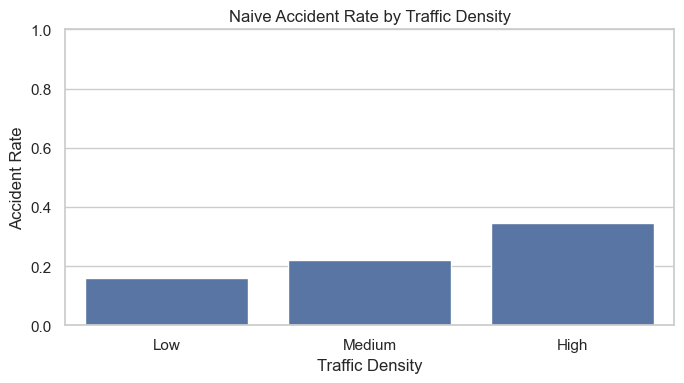

,Traffic_Density_cat,accident_rate
0,Low,0.159
1,Medium,0.220
2,High,0.347


In [5]:

assoc = df.groupby("Traffic_Density_cat")["Accident"].mean().reset_index(name="accident_rate")

plt.figure(figsize=(7, 4))
sns.barplot(data=assoc, x="Traffic_Density_cat", y="accident_rate")
plt.title("Naive Accident Rate by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Accident Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

display(assoc)



# Step 2. Confounder DAG

A confounder is a common cause of the treatment and outcome.

$$
Z \rightarrow T
$$

$$
Z \rightarrow Y
$$

$$
T \rightarrow Y
$$

For example:

$$
\text{Weather} \rightarrow \text{Traffic Density}
$$

$$
\text{Weather} \rightarrow \text{Accident}
$$


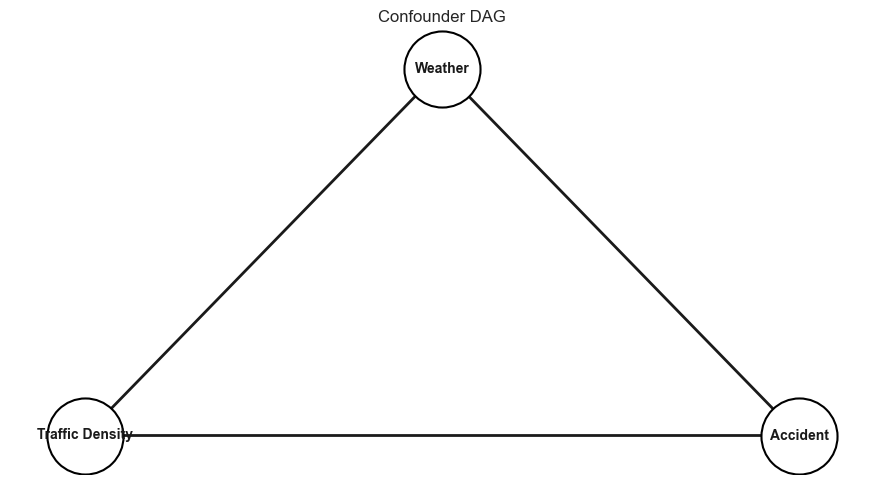

In [6]:

conf_edges = [
    ("Weather", "Traffic Density"),
    ("Weather", "Accident"),
    ("Traffic Density", "Accident")
]

conf_pos = {
    "Weather": (0, 1),
    "Traffic Density": (-1, 0),
    "Accident": (1, 0)
}

plot_dag(conf_edges, "Confounder DAG", pos=conf_pos)



## Step 2A. Visual check for confounding

We first check whether `Weather` is related to both traffic density and accidents.


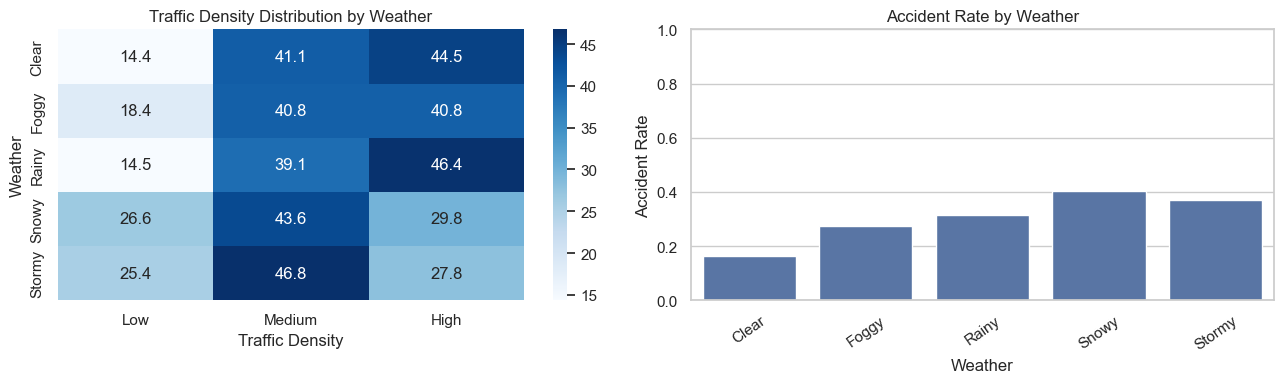

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tab = pd.crosstab(df["Weather"], df["Traffic_Density_cat"], normalize="index") * 100
sns.heatmap(tab, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Traffic Density Distribution by Weather")
axes[0].set_xlabel("Traffic Density")
axes[0].set_ylabel("Weather")

weather_rate = df.groupby("Weather")["Accident"].mean().reset_index(name="accident_rate")
sns.barplot(data=weather_rate, x="Weather", y="accident_rate", ax=axes[1])
axes[1].set_title("Accident Rate by Weather")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("Accident Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()



## Step 2B. Naive and weather-adjusted models

### Naive model

$$
\log \left( \frac{P(Y=1)}{1-P(Y=1)} \right)
=
\beta_0 + \beta_1 T
$$

### Weather-adjusted model

$$
\log \left( \frac{P(Y=1)}{1-P(Y=1)} \right)
=
\beta_0 + \beta_1 T + \gamma Z
$$


In [8]:

model_naive = smf.logit(
    "Accident ~ C(Traffic_Density_cat)",
    data=df
).fit(disp=False)

model_weather = smf.logit(
    "Accident ~ C(Traffic_Density_cat) + C(Weather)",
    data=df
).fit(disp=False)

display(odds_ratio_table(model_naive))
display(odds_ratio_table(model_weather))


,term,coef,odds_ratio,ci_low,ci_high
0,Intercept,-1.663,0.190,0.158,0.227
1,C(Traffic_Density_cat)[T.Medium],0.399,1.490,1.209,1.838
2,C(Traffic_Density_cat)[T.High],1.030,2.802,2.287,3.434


,term,coef,odds_ratio,ci_low,ci_high
0,Intercept,-2.492,0.083,0.066,0.103
1,C(Traffic_Density_cat)[T.Medium],0.525,1.690,1.363,2.095
2,C(Traffic_Density_cat)[T.High],1.274,3.576,2.891,4.424
3,C(Weather)[T.Foggy],0.733,2.081,1.681,2.576
4,C(Weather)[T.Rainy],0.872,2.391,2.017,2.833
5,C(Weather)[T.Snowy],1.463,4.321,3.470,5.380
6,C(Weather)[T.Stormy],1.333,3.794,3.036,4.741


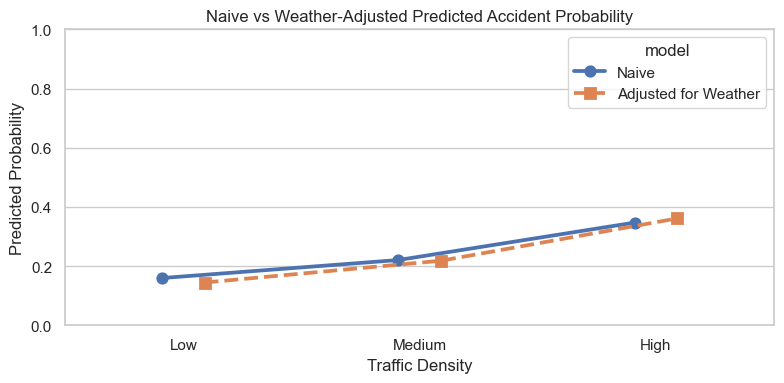

,Traffic_Density_cat,predicted_probability,model
0,Low,0.159,Naive
1,Medium,0.220,Naive
2,High,0.347,Naive
3,Low,0.144,Adjusted for Weather
4,Medium,0.218,Adjusted for Weather
5,High,0.361,Adjusted for Weather


In [9]:

pred_naive = average_predictions(model_naive, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
pred_naive["model"] = "Naive"

pred_weather = average_predictions(model_weather, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
pred_weather["model"] = "Adjusted for Weather"

pred_compare = pd.concat([pred_naive, pred_weather], ignore_index=True)

plt.figure(figsize=(8, 4))
sns.pointplot(
    data=pred_compare,
    x="Traffic_Density_cat",
    y="predicted_probability",
    hue="model",
    dodge=0.18,
    markers=["o", "s"],
    linestyles=["-", "--"]
)
plt.title("Naive vs Weather-Adjusted Predicted Accident Probability")
plt.xlabel("Traffic Density")
plt.ylabel("Predicted Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

display(pred_compare)



# Step 3. Add confounders one by one

Now we add:

$$
\text{Weather}
+
\text{Road Type}
+
\text{Road Condition}
+
\text{Time of Day}
$$

This shows how model estimates change as we block more backdoor paths.


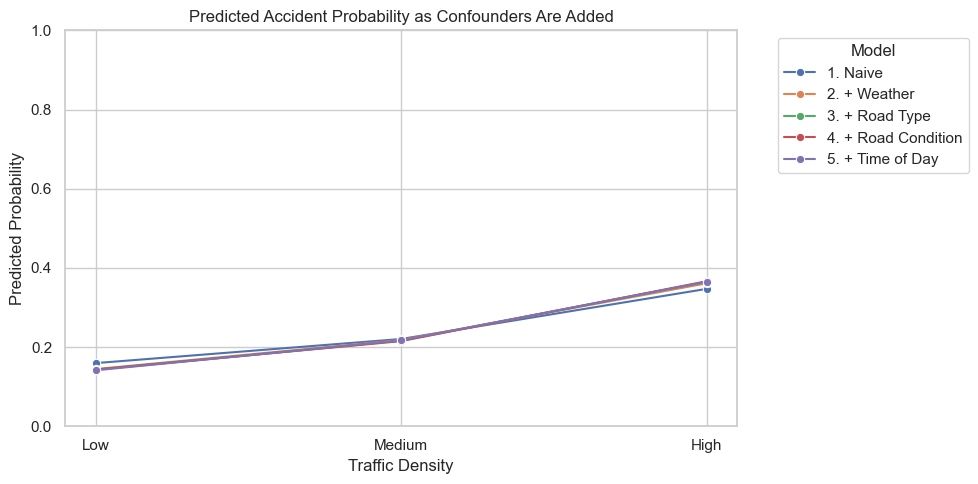

,Traffic_Density_cat,predicted_probability,model
0,Low,0.159,1. Naive
1,Medium,0.220,1. Naive
2,High,0.347,1. Naive
3,Low,0.144,2. + Weather
4,Medium,0.218,2. + Weather
5,High,0.361,2. + Weather
6,Low,0.143,3. + Road Type
7,Medium,0.216,3. + Road Type
8,High,0.365,3. + Road Type
9,Low,0.143,4. + Road Condition


In [10]:

formulas = {
    "1. Naive": "Accident ~ C(Traffic_Density_cat)",
    "2. + Weather": "Accident ~ C(Traffic_Density_cat) + C(Weather)",
    "3. + Road Type": "Accident ~ C(Traffic_Density_cat) + C(Weather) + C(Road_Type)",
    "4. + Road Condition": "Accident ~ C(Traffic_Density_cat) + C(Weather) + C(Road_Type) + C(Road_Condition)",
    "5. + Time of Day": "Accident ~ C(Traffic_Density_cat) + C(Weather) + C(Road_Type) + C(Road_Condition) + C(Time_of_Day)"
}

models = {}
preds = []

for name, formula in formulas.items():
    model = smf.logit(formula, data=df).fit(disp=False)
    models[name] = model
    pred = average_predictions(model, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
    pred["model"] = name
    preds.append(pred)

pred_sequence = pd.concat(preds, ignore_index=True)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=pred_sequence,
    x="Traffic_Density_cat",
    y="predicted_probability",
    hue="model",
    marker="o"
)
plt.title("Predicted Accident Probability as Confounders Are Added")
plt.xlabel("Traffic Density")
plt.ylabel("Predicted Probability")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(pred_sequence)



# Step 4. Mediator DAG

A mediator lies on the causal path from treatment to outcome.

$$
T \rightarrow M \rightarrow Y
$$

In our case:

$$
\text{Traffic Density} \rightarrow \text{Number of Vehicles} \rightarrow \text{Accident}
$$

If we control for the mediator, the interpretation changes from a total-effect model to a direct-effect-oriented model.


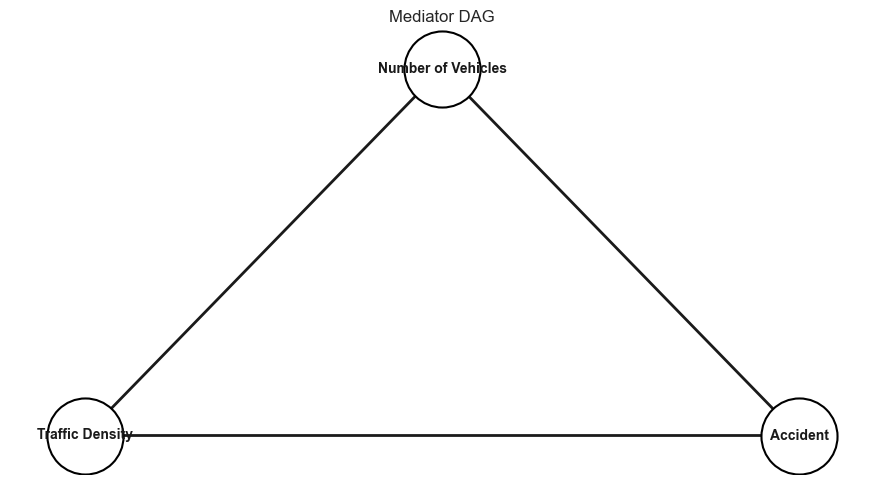

In [11]:

med_edges = [
    ("Traffic Density", "Number of Vehicles"),
    ("Number of Vehicles", "Accident"),
    ("Traffic Density", "Accident")
]

med_pos = {
    "Traffic Density": (-1, 0),
    "Number of Vehicles": (0, 1),
    "Accident": (1, 0)
}

plot_dag(med_edges, "Mediator DAG", pos=med_pos)


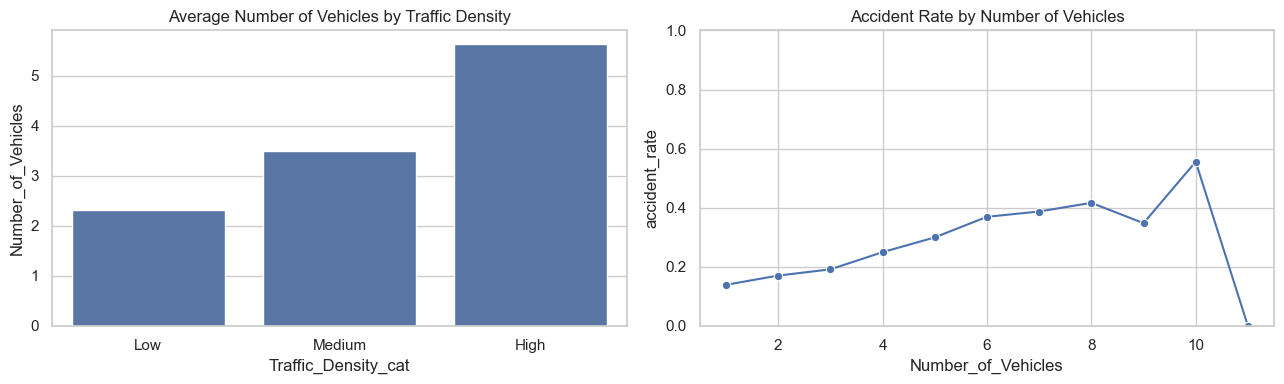

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mean_vehicles = df.groupby("Traffic_Density_cat")["Number_of_Vehicles"].mean().reset_index()
sns.barplot(data=mean_vehicles, x="Traffic_Density_cat", y="Number_of_Vehicles", ax=axes[0])
axes[0].set_title("Average Number of Vehicles by Traffic Density")

vehicle_rate = df.groupby("Number_of_Vehicles")["Accident"].mean().reset_index(name="accident_rate")
sns.lineplot(data=vehicle_rate, x="Number_of_Vehicles", y="accident_rate", marker="o", ax=axes[1])
axes[1].set_title("Accident Rate by Number of Vehicles")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


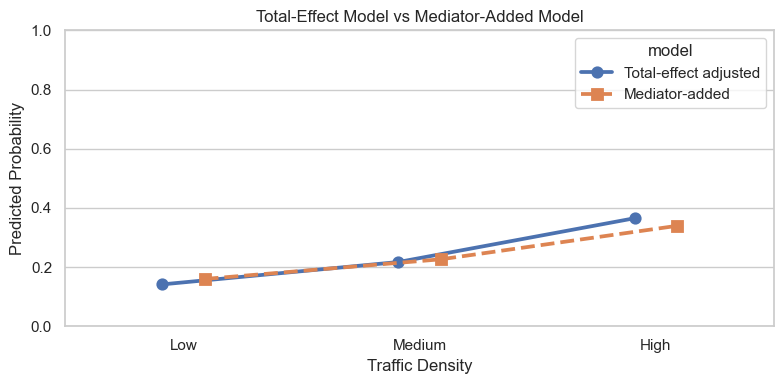

,Traffic_Density_cat,predicted_probability,model
0,Low,0.141,Total-effect adjusted
1,Medium,0.217,Total-effect adjusted
2,High,0.365,Total-effect adjusted
3,Low,0.160,Mediator-added
4,Medium,0.226,Mediator-added
5,High,0.339,Mediator-added


In [13]:

total_effect_model = models["5. + Time of Day"]

mediator_model = smf.logit(
    "Accident ~ C(Traffic_Density_cat) + C(Weather) + C(Road_Type) + C(Road_Condition) + C(Time_of_Day) + Number_of_Vehicles",
    data=df
).fit(disp=False)

pred_total = average_predictions(total_effect_model, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
pred_total["model"] = "Total-effect adjusted"

pred_mediator = average_predictions(mediator_model, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
pred_mediator["model"] = "Mediator-added"

pred_med = pd.concat([pred_total, pred_mediator], ignore_index=True)

plt.figure(figsize=(8, 4))
sns.pointplot(
    data=pred_med,
    x="Traffic_Density_cat",
    y="predicted_probability",
    hue="model",
    dodge=0.18,
    markers=["o", "s"],
    linestyles=["-", "--"]
)
plt.title("Total-Effect Model vs Mediator-Added Model")
plt.xlabel("Traffic Density")
plt.ylabel("Predicted Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

display(pred_med)



# Step 5. Collider DAG

A collider is caused by two variables:

$$
X \rightarrow C \leftarrow Y
$$

A teaching example in this dataset is:

$$
\text{Road Type} \rightarrow \text{Road Light Condition} \leftarrow \text{Time of Day}
$$

Conditioning on a collider can create spurious association.


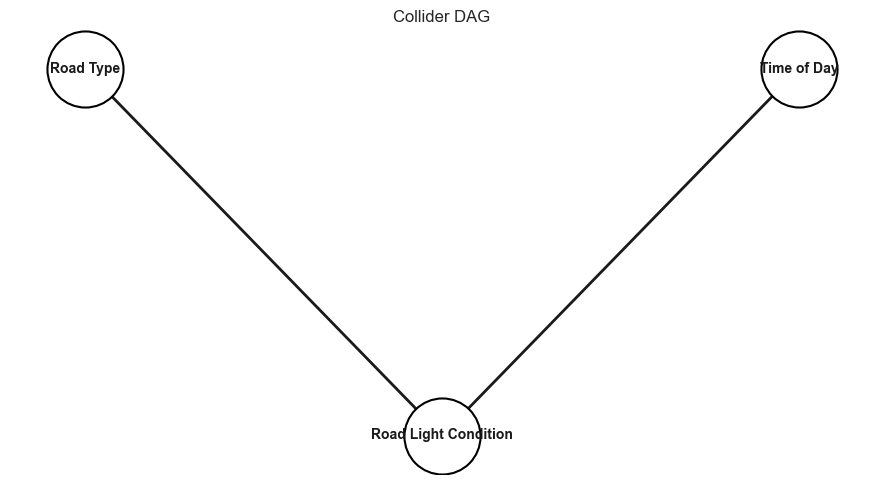

In [14]:

collider_edges = [
    ("Road Type", "Road Light Condition"),
    ("Time of Day", "Road Light Condition")
]

collider_pos = {
    "Road Type": (-1, 1),
    "Time of Day": (1, 1),
    "Road Light Condition": (0, 0)
}

plot_dag(collider_edges, "Collider DAG", pos=collider_pos)


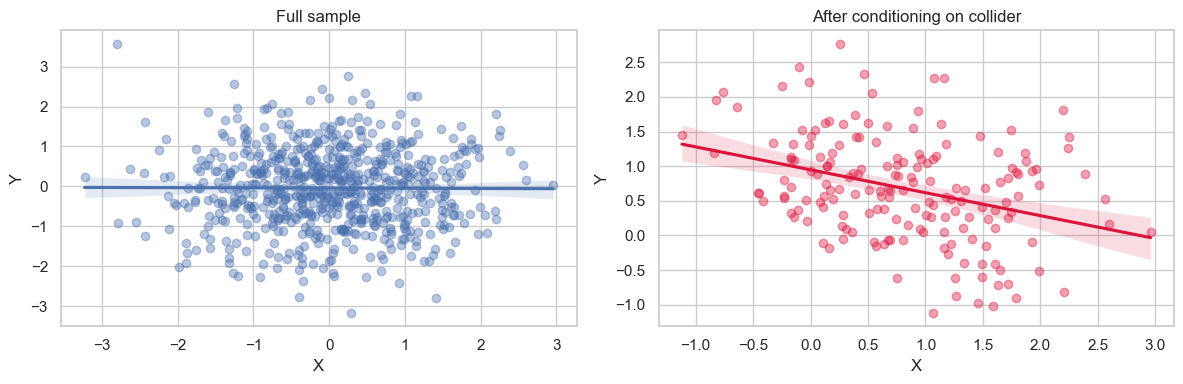

Overall correlation: -0.005
Correlation after conditioning: -0.342


In [15]:

# Simulated collider demonstration
np.random.seed(123)

n_sim = 700
X = np.random.normal(size=n_sim)
Y = np.random.normal(size=n_sim)
C = X + Y + np.random.normal(scale=0.7, size=n_sim)

sim = pd.DataFrame({"X": X, "Y": Y, "C": C})
sim["condition_on_collider"] = sim["C"] > sim["C"].quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(data=sim, x="X", y="Y", ax=axes[0], scatter_kws={"alpha": 0.4})
axes[0].set_title("Full sample")

sns.regplot(
    data=sim[sim["condition_on_collider"]],
    x="X",
    y="Y",
    ax=axes[1],
    scatter_kws={"alpha": 0.4},
    color="crimson"
)
axes[1].set_title("After conditioning on collider")

plt.tight_layout()
plt.show()

print("Overall correlation:", round(sim[["X", "Y"]].corr().iloc[0, 1], 3))
print("Correlation after conditioning:", round(sim.loc[sim["condition_on_collider"], ["X", "Y"]].corr().iloc[0, 1], 3))



# Step 6. Final comparison

We now compare three model logics:

$$
Y \sim T
$$

$$
Y \sim T + Z
$$

$$
Y \sim T + Z + M
$$

They answer different questions.


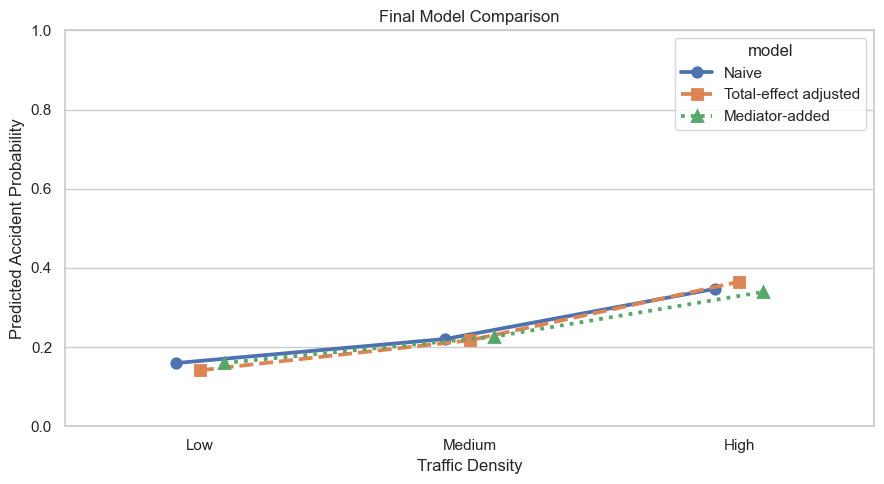

,Traffic_Density_cat,predicted_probability,model
0,Low,0.159,Naive
1,Medium,0.220,Naive
2,High,0.347,Naive
3,Low,0.141,Total-effect adjusted
4,Medium,0.217,Total-effect adjusted
5,High,0.365,Total-effect adjusted
6,Low,0.160,Mediator-added
7,Medium,0.226,Mediator-added
8,High,0.339,Mediator-added


In [16]:

final_models = {
    "Naive": model_naive,
    "Total-effect adjusted": total_effect_model,
    "Mediator-added": mediator_model
}

final_preds = []
for name, model in final_models.items():
    pred = average_predictions(model, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
    pred["model"] = name
    final_preds.append(pred)

final_preds = pd.concat(final_preds, ignore_index=True)

plt.figure(figsize=(9, 5))
sns.pointplot(
    data=final_preds,
    x="Traffic_Density_cat",
    y="predicted_probability",
    hue="model",
    dodge=0.18,
    markers=["o", "s", "^"],
    linestyles=["-", "--", ":"]
)
plt.title("Final Model Comparison")
plt.xlabel("Traffic Density")
plt.ylabel("Predicted Accident Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

display(final_preds)



## Final lesson

The correct question is not:

$$
\text{Which model has more variables?}
$$

The correct question is:

$$
\text{Which model matches the DAG and the causal estimand?}
$$

For a total-effect question, use:

$$
Y \sim T + Z
$$

For a direct-effect question, use:

$$
Y \sim T + Z + M
$$
